In [1]:
import pandas as pd# Import necessary libraries
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import os
from pyproj import CRS
import zipfile
import glob
import plotly.graph_objects as go
import json
import xml.etree.ElementTree as ET
from typing import Dict, Any
from supabase import create_client, Client
from dotenv import load_dotenv
# Import necessary libraries
import numpy as np
import pandas as pd
import os

load_dotenv()

True

1. Upload project kml shape as jsonb to supabase
&
2. Create Donut Shapefile from Project KML -> Zipped Shapefile


In [ ]:
class KMLtoSupabasePipeline:
    def __init__(self, project_code: str, gdf: gpd.GeoDataFrame):
        """Initialize the pipeline with Supabase credentials"""
        self.supabase: Client = client
        self.project_code = project_code 
        self.gdf = gdf
        
    def gdf_to_geojson(self) -> Dict[str, Any]:
        """Convert GDF to GeoJSON format"""
        try:
            # Convert to GeoJSON
            geojson_data = json.loads(self.gdf.to_json())
            return geojson_data
            
        except Exception as e:
            print(f"Error converting GDF to GeoJSON: {str(e)}")
            return None
        
    def get_project_id(self) -> str:
        """Retrieve project_id from projects table using project_code"""
        try:
            response = (self.supabase.table("projects")
                       .select("id")
                       .eq("project_code", self.project_code)
                       .execute())
            if response.data and len(response.data) > 0:
                return response.data[0]["id"]
            print(f"No project found with project_code: {self.project_code}")
            return None
        except Exception as e:
            print(f"Error retrieving project_id: {str(e)}")
            return None
        
    def upload_to_supabase(self, geojson_data: Dict[str, Any], project_id: str, table_name: str = "geo_data"):
        """Upload GeoJSON to Supabase with project_code matching"""
        try:
            # Prepare data for Supabase
            data = {
                "project_id": project_id,
                "geometry": geojson_data,
            }

            # Check if project_code exists
            existing = (self.supabase.table(table_name)
                       .select("project_id")
                       .eq("project_id", project_id)
                       .execute())
            
            if len(existing.data) > 0:
                # Update existing record
                response = (self.supabase.table(table_name)
                          .update(data)
                          .eq("project_id", project_id)
                          .execute())
            else:
                # Insert new record
                response = self.supabase.table(table_name).insert(data).execute()
                
            return response
            
        except Exception as e:
            print(f"Error uploading to Supabase: {str(e)}")
            return None

    def process_file(self, table_name: str = "geo_data", ):
        """Main pipeline method to process KML file and upload to Supabase"""
        # Step 1: Convert KML to GeoJSON
        geojson_data = self.gdf_to_geojson()
        if not geojson_data:
            return False
        
        # Step 2: Get project_id for the project_code
        project_id = self.get_project_id()
        if not project_id:
            return False

        # Step 2: Upload to Supabase
        response = self.upload_to_supabase(geojson_data, project_id, table_name)
        
        if response:
            print(f"Successfully processed with project_code: {self.project_code}")
            return True
        return False
    
    def make_donut(self):
        # Set output directory and filename (without extension)
        output_dir = "/Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/data/proj_shape/donut_buffer"
        output_filename = f"{self.project_code}_buffered_geometry_donut"

        # Create output directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)

        # Print original CRS information
        print(f"Original CRS: {self.gdf.crs}")

        # If the CRS is not set (common with KML files), assume it's EPSG:4326 (WGS84)
        if self.gdf.crs is None:
            self.gdf.crs = CRS.from_epsg(4326)
            print("Set CRS to EPSG:4326 (WGS84)")

        # Transform to Web Mercator (EPSG:3857)
        gdf_web_mercator = self.gdf.to_crs(epsg=3857)
        print(f"New CRS: {gdf_web_mercator.crs}")

        # Buffer by 10km (10,000 meters in Web Mercator)
        gdf_buffered = gdf_web_mercator.copy()
        gdf_buffered['geometry'] = gdf_web_mercator.geometry.buffer(10000)
        
        # first create a union of all ring geometries
        unified_buffer = None
        for geom in gdf_buffered.geometry:
            if unified_buffer is None:
                unified_buffer = geom
            else:
                unified_buffer = unified_buffer.union(geom)
            
        # Create the ring by subtracting the original geometries from the unified buffer
        # First, create a union of all original geometries
        unified_original = None
        for geom in gdf_web_mercator.geometry:
            if unified_original is None:
                unified_original = geom
            else:
                unified_original = unified_original.union(geom)

        # Now create the ring by subtracting the unified original from the unified buffer
        ring_geometry = unified_buffer.difference(unified_original)

        unified_ring = gpd.GeoDataFrame(geometry=[ring_geometry], crs=gdf_web_mercator.crs)
        
        # Plot to visualize the results
        fig, ax = plt.subplots(1, 3, figsize=(18, 6))

        # Plot original geometry
        gdf_web_mercator.plot(ax=ax[0], color='blue', alpha=0.5)
        ax[0].set_title('Original Geometry')

        # Plot buffered geometry
        gdf_buffered.plot(ax=ax[1], color='red', alpha=0.5)
        ax[1].set_title('Buffered Geometry (10km)')

        # Plot ring geometry (buffer minus original)
        unified_ring.plot(ax=ax[2], color='green', alpha=0.5)
        ax[2].set_title('Union Ring Geometry (10km buffer minus original)')

        # Add original geometry outline to all plots for reference
        for i in range(3):
            gdf_web_mercator.boundary.plot(ax=ax[i], color='blue', linewidth=1)

        plt.tight_layout()
        plt.show()

        # Print information about the geometries
        print(f"Original area: {gdf_web_mercator.area.sum()} square meters")
        print(f"Buffered area: {gdf_buffered.area.sum()} square meters")
        print(f"Union Ring area: {unified_ring.area.sum()} square meters")

        # Save the buffered geometry as a shapefile
        output_shapefile = os.path.join(output_dir, output_filename)
        unified_ring.to_file(output_shapefile, driver="ESRI Shapefile")
        print(f"Saved buffered geometry to {output_shapefile}.shp (and related files)")

        return True

3. Upload to GEE and Process with : [Prod]_Class_TimeSeries_Moving_Avg -> CSV 

4. Load Landuse & Forest Loss csv and upload to supabase

In [ ]:
class CSVtoSupabasePipeline:
    def __init__(self, project_code: str):
        """Initialize the pipeline with Supabase credentials"""
        self.supabase: Client = client
        self.project_code = project_code 
        self.landuse_file_path = f'/Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/data/gee_csv/landclass_moveAvg_2016to2025_res10_{self.project_code}.csv'
        self.forestloss_file_path = f'/Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/data/gee_csv/forestloss_gfw_res30_{self.project_code}.csv'
        self.df_landuse = pd.read_csv(self.landuse_file_path)
        self.df_forestloss = pd.read_csv(self.forestloss_file_path)
        
    def get_project_id(self) -> str:
        """Retrieve project_id from projects table using project_code"""
        try:
            response = (self.supabase.table("projects")
                       .select("id")
                       .eq("project_code", self.project_code)
                       .execute())
            if response.data and len(response.data) > 0:
                return response.data[0]["id"]
            print(f"No project found with project_code: {self.project_code}")
            return None
        except Exception as e:
            print(f"Error retrieving project_id: {str(e)}")
            return None
        
    def upload_to_supabase_landuse(self, project_id: str, table_name: str = "landuse_time_series"):
        """Upload land use time series to Supabase with project_id matching"""
        
        # Add project_id to all rows
        self.df_landuse["project_id"] = project_id
        
        # TODO rename the column names to match the table schema
        self.df_landuse.rename(columns={
            '0': 'water', 0: 'water',
            '1': 'trees', 1: 'trees',
            '2': 'grass', 2: 'grass',
            '3': 'flooded_vegetation', 3: 'flooded_vegetation',
            '4': 'crops', 4: 'crops',
            '5': 'shrub_and_scrub', 5: 'shrub_and_scrub',
            '6': 'built', 6: 'built',
            '7': 'bare', 7: 'bare',
            '8': 'snow_and_ice', 8: 'snow_and_ice',
            '9': 'null', 9: 'null'
        }, inplace=True)
        self.df_landuse.head(2)
        
        columns = [
            'project_id', 'month', 'bare', 'built', 'crops', 
            'flooded_vegetation', 'grass', 'shrub_and_scrub', 
            'snow_and_ice', 'trees', 'water', 'null'
        ] 
        df_upload = self.df_landuse[columns]
        
        # Fill NA & Replace infinity values
        df_upload = df_upload.fillna(0)
        df_upload = df_upload.replace([np.inf, -np.inf], 0)
            
        try:
            # First, delete existing records for this project to avoid duplicates
            delete_response = (self.supabase.table(table_name)
                              .delete()
                              .eq("project_id", project_id)
                              .execute())
            
            print(f"Deleted {len(delete_response.data)} existing records")
            
            # Then insert all new records
            data = df_upload.to_dict(orient='records')
            
            # Insert in batches if there are many records
            batch_size = 100
            for i in range(0, len(data), batch_size):
                batch = data[i:i+batch_size]
                response = self.supabase.table(table_name).insert(batch).execute()
                print(f"Inserted batch {i//batch_size + 1}/{(len(data) + batch_size - 1)//batch_size}")
            
            print(f"Successfully uploaded {len(data)} records for project {project_id}")
            return True
        
        except Exception as e:
            print(f"Error uploading to Supabase: {str(e)}")
            return None
        
    def upload_to_supabase_forestloss(self, project_id: str, table_name: str = "time_series_data"):
        """Upload forest loss time series to Supabase with project_id matching"""
        
        # Add project_id to all rows
        self.df_forestloss["project_id"] = project_id

        # TODO rename the column names to match the table schema
        self.df_forestloss.rename(columns={
            'year': 'timestamp',
            'deforestation_amount': 'deforestation_area'
        }, inplace=True)
        
        columns = ['project_id', 'timestamp', 'deforestation_area'] 
        df_upload = self.df_forestloss[columns]
        
        # Fill NA & Replace infinity values
        df_upload = df_upload.fillna(0)
        df_upload = df_upload.replace([np.inf, -np.inf], 0)
                
        try:
            # First, delete existing records for this project to avoid duplicates
            delete_response = (self.supabase.table(table_name)
                              .delete()
                              .eq("project_id", project_id)
                              .execute())
            
            print(f"Deleted {len(delete_response.data)} existing records")
            
            # Then insert all new records
            data = df_upload.to_dict(orient='records')
            
            # Insert in batches if there are many records
            batch_size = 100
            for i in range(0, len(data), batch_size):
                batch = data[i:i+batch_size]
                response = self.supabase.table(table_name).insert(batch).execute()
                print(f"Inserted batch {i//batch_size + 1}/{(len(data) + batch_size - 1)//batch_size}")
            
            print(f"Successfully uploaded {len(data)} records for project {project_id}")
            return True
        
        except Exception as e:
            print(f"Error uploading to Supabase: {str(e)}")
            return None
        
    def plotting_landuse(self):        
        # Define columns to plot (exclude 'month' and 'system:index')
        value_columns = [
            'water', 
            'bare', 'built', 'snow_and_ice', 
            'grass',
            'crops',
            'shrub_and_scrub', 
            'flooded_vegetation', 
            'trees', 
            'null'
            ]

        # Create a stacked area chart using Plotly
        fig = go.Figure()

        # Add a trace for each value column
        for col in value_columns:
            fig.add_trace(
                go.Scatter(
                    x=self.df_landuse['month'],
                    y=self.df_landuse[col],
                    mode='lines',
                    name=col,
                    stackgroup='one',  # Stack the areas
                    line=dict(width=0.5)
                )
            )

        # Update layout for better visualization
        fig.update_layout(
            title='Monthly Pixel Counts by Land Cover Class (2024)',
            xaxis_title='Month',
            yaxis_title='Pixel Count',
            xaxis=dict(tickangle=45),
            legend_title='Class',
            hovermode='x unified',
            template='plotly_white',
            showlegend=True
        )

        # Display the chart (in a Jupyter notebook or similar environment)
        fig.show()

        # Optionally, save the chart as an HTML file for sharing
        fig.write_html('stacked_area_chart.html')
        
        return "plotted successfully"
    
    # Main function to run the pipeline
    def process_landuse_pipeline(self):
        """
        Run the complete pipeline to upload land use time series data.
        
        Parameters:
        - project_code: The project code to link the data to
        """
        # Check if the project code exists
        if not self.get_project_id():
            print(f"Error: Project code '{self.project_code}' does not exist in the projects table")
            return False
        
        # Upload the data
        success = self.upload_to_supabase_landuse(self.get_project_id(), table_name = "landuse_time_series")
        
        if success:
            print(f"Pipeline completed successfully for project code: {self.project_code}")
        else:
            print(f"Pipeline failed for project code: {self.project_code}")
        
        # plot the file 
        self.plotting_landuse()
        
        return success
    
    def process_foresloss_pipeline(self):
        """
        Run the complete pipeline to upload forestloss time series data.
        
        Parameters:
        - project_code: The project code to link the data to
        """
        # Check if the project code exists
        project_id = self.get_project_id()
        if not project_id:
            print(f"Error: Project code '{self.project_code}' does not exist in the projects table")
            return False
        print(f"project id is {project_id}")
        # Upload the data
        success = self.upload_to_supabase_forestloss(project_id, table_name = "time_series_data")
        
        if success:
            print(f"Pipeline completed successfully for project code: {self.project_code}")
        else:
            print(f"Pipeline failed for project code: {self.project_code}")
        
        # # plot the file 
        # self.plotting_landuse()
        return success


Steps:
1. Upload project kml shape as jsonb to supabase
------
2. Create Donut Shapefile from Project KML -> Zipped Shapefile
3. Upload to GEE and Process with : [Prod]_Class_TimeSeries_Moving_Avg -> CSV 
------
4. Load the landuse csv and upload to supabase

# Actual Processing

## STEP1: Upload project kml shape as jsonb to supabase

In [ ]:
# Set the path to your KML file - replace with your actual KML file path
project_code = "3226"

In [ ]:
kml_file_path = f'/Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/data/proj_shape/{project_code}.kml'
# Load the KML file
gdf = gpd.read_file(kml_file_path, driver='KML')
# Create supabase client
client = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))
# Initialize pipeline
pipeline = KMLtoSupabasePipeline(project_code, gdf)

In [ ]:
# Upload the file
success_kmlUpload = pipeline.process_file()
if success_kmlUpload:
    print(f"project {project_code} kml to jsonb file upload completed successfully")
else:
    print(f"project {project_code} kml to jsonb file upload failed")

## STEP2 - Donut, THEN PROCESS IT WITH GEE [Prod]_Class_TimeSeries_Moving_Avg -> CSV 
2. Create Donut Shapefile from Project KML -> Zipped Shapefile
3. Upload to GEE and Process with : [Prod]_Class_TimeSeries_Moving_Avg -> CSV 

Original CRS: EPSG:4326
New CRS: EPSG:3857


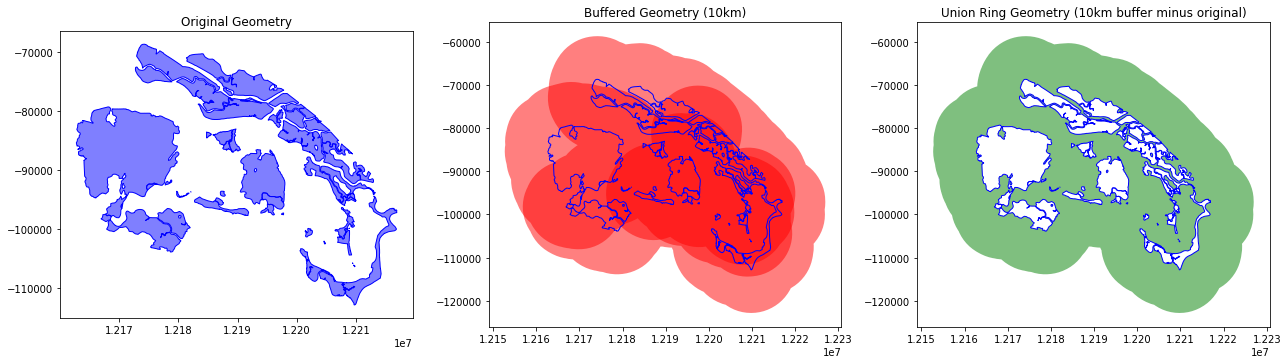

Original area: 591346620.2980621 square meters
Buffered area: 6222923152.061195 square meters
Union Ring area: 2649306427.901248 square meters
Saved buffered geometry to /Users/beckyxu/Documents/GitHub/Carbon_Offset_Validation/carbon-offset-validator/data/proj_shape/donut_buffer/3226_buffered_geometry_donut.shp (and related files)


True

In [43]:
# Make donut
pipeline.make_donut()

## STEP3 - EXTERNAL!!! GEE

Zip & Upload to GEE : Assets -> Shapefiles

Process with : 

1. [Prod]_Class_TimeSeries_MovingAvg_DW -> CSV -> SUPABASE
2. [Prod]_ForestLoss_TimeSerie_GFW_csv -> CSV -> SUPABASE

# STEP4 - Load the landuse csv and upload to supabase

In [96]:
# load data frame from csv project_code
landuse_pipeline = CSVtoSupabasePipeline(project_code=project_code)

In [76]:
landuse_pipeline.process_landuse_pipeline()

Deleted 99 existing records
Inserted batch 1/1
Successfully uploaded 99 records for project 084650fe-b1f5-44d4-9a40-a7d4e7f42f30
Pipeline completed successfully for project code: 3226


True

# STEP5 - Load the forestloss csv and upload to supabase

In [99]:
landuse_pipeline.process_foresloss_pipeline()

project id is 084650fe-b1f5-44d4-9a40-a7d4e7f42f30
   system:index  deforestation_area  timestamp  \
0             0        2.527090e+06       2001   
1             1        7.331419e+06       2002   

                                     .geo  \
0  {"type":"MultiPoint","coordinates":[]}   
1  {"type":"MultiPoint","coordinates":[]}   

                             project_id  
0  084650fe-b1f5-44d4-9a40-a7d4e7f42f30  
1  084650fe-b1f5-44d4-9a40-a7d4e7f42f30  
Deleted 23 existing records
Inserted batch 1/1
Successfully uploaded 23 records for project 084650fe-b1f5-44d4-9a40-a7d4e7f42f30
Pipeline completed successfully for project code: 3226


True